# FRED Data Research Notebook

This notebook is for a clean macro research workflow using FRED data. Use it to:
- define the research question
- pull the required series
- validate the data quality
- test transformations and features
- decide whether the idea should become a reusable source module or POC

## Research objective
Define the question in one sentence, for example:
- Does the yield curve slope predict recession risk?
- Does inflation persistence drive growth slowdown?
- Are interest-rate changes associated with volatility regime shifts?

- https://fred.stlouisfed.org/categories/

In [18]:
research_question = "How do macro rates and inflation behave during stress periods?"
research_question_2 = "Does a flattening or inverted yield curve predict rising unemployment over the next 12 months?"
print("Research question:", research_question)
print("Secondary unemployment question:", research_question_2)

Research question: How do macro rates and inflation behave during stress periods?
Secondary unemployment question: Does a flattening or inverted yield curve predict rising unemployment over the next 12 months?


## 1. Select the FRED series
Pick the series that map to your hypothesis.

Common macro series:
- `FEDFUNDS` — Federal Funds Rate
- `CPIAUCSL` — CPI Level
- `CPILFESL` — Core CPI
- `UNRATE` — Unemployment Rate
- `GDPC1` — Real GDP
- `DGS10` — 10Y Treasury Yield
- `DGS3MO` — 3M Treasury Yield

In [19]:
series_map = {
    "fed_funds": "FEDFUNDS",
    "cpi": "CPIAUCSL",
    "core_cpi": "CPILFESL",
    "unemployment": "UNRATE",
    "treasury_10y": "DGS10",
    "treasury_3m": "DGS3MO",
}

print("Selected FRED series:")
for name, sid in series_map.items():
    print(f"- {name}: {sid}")

Selected FRED series:
- fed_funds: FEDFUNDS
- cpi: CPIAUCSL
- core_cpi: CPILFESL
- unemployment: UNRATE
- treasury_10y: DGS10
- treasury_3m: DGS3MO


In [20]:
# Pull macro data
start_date = "1980-01-01"
end_date = None
frequency = "m"

frames = {}
for name, sid in series_map.items():
    s = fred.get_series(
        sid,
        observation_start=start_date,
        observation_end=end_date,
        frequency=frequency,
    )
    frames[name] = s.rename(name)

macro_df = pd.concat(frames, axis=1).sort_index()
print(macro_df.head())
print(f"\nShape: {macro_df.shape}")

            fed_funds   cpi  core_cpi  unemployment  treasury_10y  treasury_3m
1980-01-01      13.82  78.0      76.7           6.3         10.80          NaN
1980-02-01      14.13  79.0      77.5           6.3         12.41          NaN
1980-03-01      17.19  80.1      78.6           6.3         12.75          NaN
1980-04-01      17.61  80.9      79.5           6.9         11.47          NaN
1980-05-01      10.98  81.7      80.1           7.5         10.18          NaN

Shape: (561, 6)


## 2. Validate FRED data quality
Check missing data, duplicates, and basic consistency.

In [21]:
# Validate data quality
if macro_df.empty:
    raise ValueError("FRED data is empty.")

assert not macro_df.index.has_duplicates, "Duplicate dates found."
missing = macro_df.isna().sum()
print("Missing values:\n", missing[missing > 0])

macro_df = macro_df.dropna()
print("Cleaned shape:", macro_df.shape)

Missing values:
 fed_funds        1
cpi              2
core_cpi         2
unemployment     2
treasury_10y     1
treasury_3m     21
dtype: int64
Cleaned shape: (539, 6)


In [22]:
# Quick summary statistics
summary = macro_df.describe().T
print(summary.round(4))

              count      mean      std    min      25%     50%       75%  \
fed_funds     539.0    4.0157   3.3054   0.05    1.000    4.01    5.8100   
cpi           539.0  192.9693  63.0834  93.10  142.200  186.70  237.4685   
core_cpi      539.0  198.2841  63.2143  91.80  149.400  194.90  241.5170   
unemployment  539.0    5.9525   1.8252   3.40    4.500    5.60    7.1000   
treasury_10y  539.0    5.3653   3.0529   0.62    2.905    4.60    7.1750   
treasury_3m   539.0    3.8305   3.1158   0.01    0.940    3.94    5.5850   

                  max  
fed_funds      15.870  
cpi           334.131  
core_cpi      337.765  
unemployment   14.800  
treasury_10y   15.320  
treasury_3m    15.610  


## 3. Create macro features
Create simple economically meaningful transforms.

In [23]:
# Macro feature engineering
features = macro_df.copy()
features["term_spread"] = features["treasury_10y"] - features["treasury_3m"]
features["cpi_yoy"] = features["cpi"].pct_change(12) * 100
features["fed_funds_12m_change"] = features["fed_funds"].pct_change(12) * 100
features["unemployment_12m_change"] = features["unemployment"].diff(12)
features["unemployment_yoy_change"] = features["unemployment"].pct_change(12) * 100

print(features[["term_spread", "cpi_yoy", "fed_funds_12m_change", "unemployment_12m_change", "unemployment_yoy_change"]].tail())

            term_spread   cpi_yoy  fed_funds_12m_change  \
2026-04-01         0.62  3.947027            -15.935335   
2026-05-01         0.79  4.270033            -16.166282   
2026-06-01         0.66  3.726530            -16.166282   
2026-07-01         0.73  3.539751            -16.166282   
2026-08-01         0.80  3.712958            -16.166282   

            unemployment_12m_change  unemployment_yoy_change  
2026-04-01                      0.1                 2.380952  
2026-05-01                      0.1                 2.380952  
2026-06-01                     -0.1                -2.325581  
2026-07-01                      0.0                 0.000000  
2026-08-01                     -0.2                -4.651163  


## 4. Plot the core relationships
Use a simple chart to inspect the relationship visually.

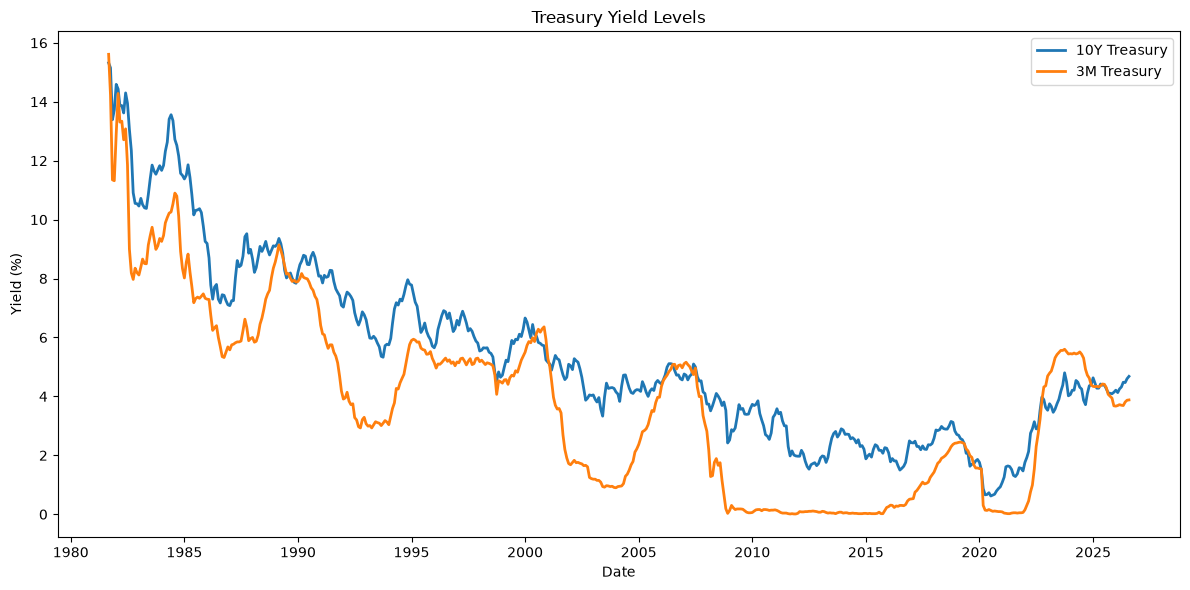

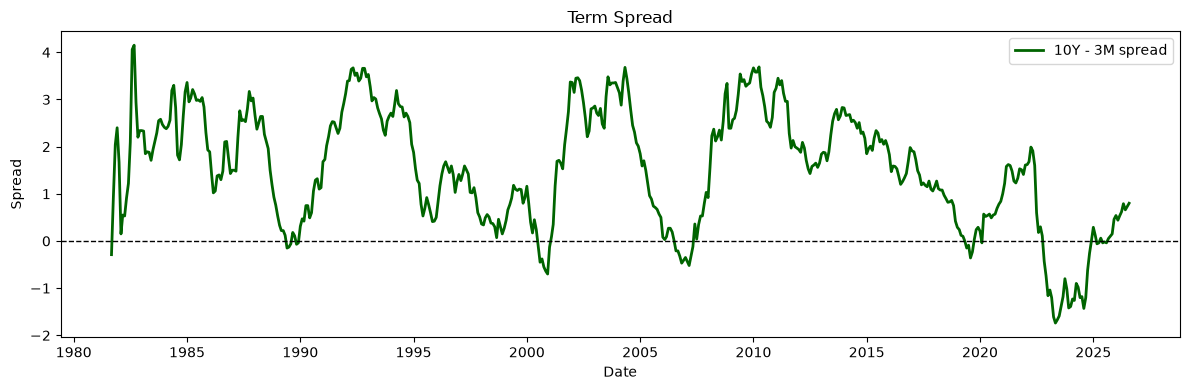

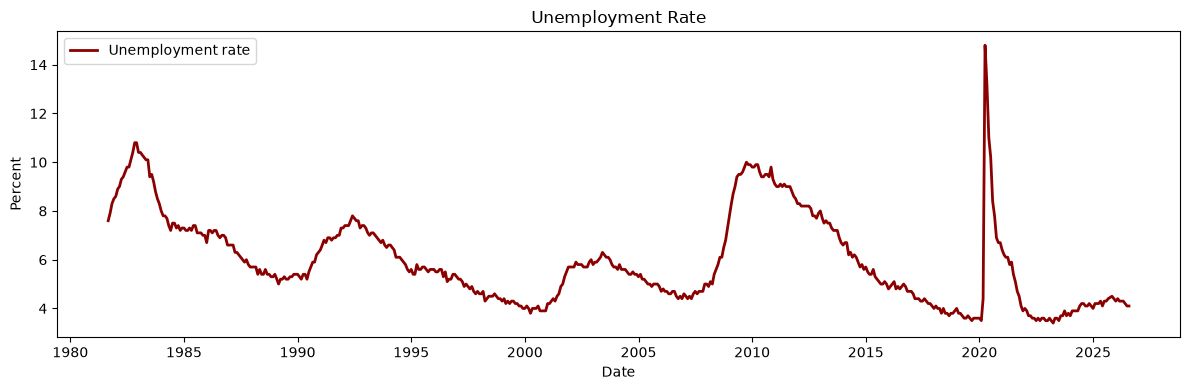

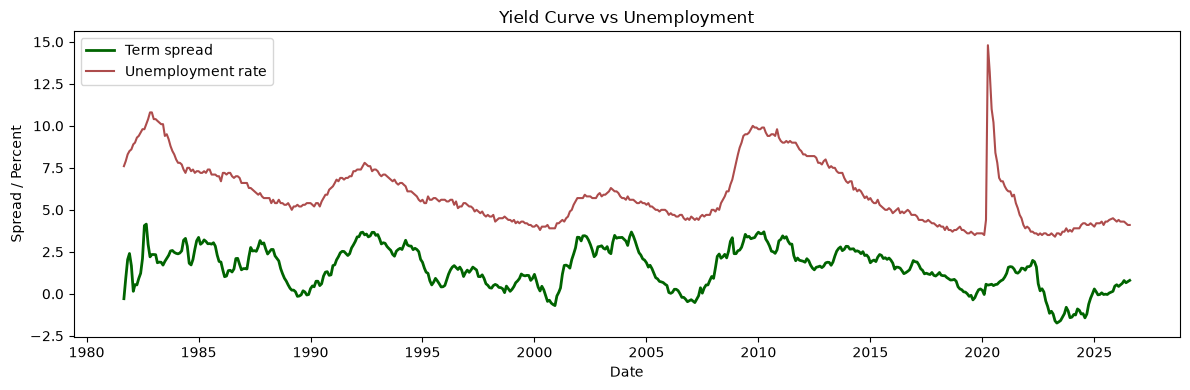

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(features["treasury_10y"], label="10Y Treasury", linewidth=2)
plt.plot(features["treasury_3m"], label="3M Treasury", linewidth=2)
plt.title("Treasury Yield Levels")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(features["term_spread"], label="10Y - 3M spread", color="darkgreen", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Term Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(features["unemployment"], label="Unemployment rate", color="darkred", linewidth=2)
plt.title("Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(features["term_spread"], label="Term spread", color="darkgreen", linewidth=2)
plt.plot(features["unemployment"], label="Unemployment rate", color="darkred", linewidth=1.5, alpha=0.7)
plt.title("Yield Curve vs Unemployment")
plt.xlabel("Date")
plt.ylabel("Spread / Percent")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Interpret the signal
Document what the data suggests before moving into a more formal strategy.

Possible interpretations:
- widening term spread -> stronger growth expectations
- rising inflation -> policy pressure and risk-off environment
- unemployment drift -> cyclical stress signal
- flattening or inverted yield curve followed by higher unemployment -> recession warning

For this unemployment question, the most relevant test is:
- if the 10Y-3M spread narrows or turns negative, does unemployment rise in the next 6-12 months?


In [8]:
# Example result summary
interpretation = {
    "question": research_question,
    "status": "prototype",
    "next_step": "Convert this notebook logic into a reusable macro signal module or POC script.",
}

print(interpretation)

{'question': 'How do macro rates and inflation behave during stress periods?', 'status': 'prototype', 'next_step': 'Convert this notebook logic into a reusable macro signal module or POC script.'}


## 6. Final decision
Decide if this should become:
- a reusable data ingestion module
- a macro feature engineering script
- a strategy idea
- a full alpha research workflow